# Практична робота 4.13. Частина 2 (групова): Reinforcement learning, DQN-агент для маршруту логістичного забезпечення

**Номер за журналом:** 7 · Частина 1 (transfer learning) міститься у ноутбуці `4.13_1_transfer_learning.ipynb`.

**Задача (з переліку викладача: «оптимізація логістичних маршрутів доставки ресурсів у змінних умовах бойової обстановки»).**
Колона має дійти від пункту постачання **S** до підрозділу **G**. Між ними проходить рубіж із двома переправами:
- **коротка переправа** (центр карти) може бути **під вогнем противника**;
- **довга переправа** (обхід знизу) безпечна, але на 10 кроків довша.

**Змінні умови.** Перед кожним рейсом розвідка повідомляє, чи коротка переправа зараз під вогнем (імовірність 50 %). Під час руху з імовірністю 10 % колону зносить у випадковому напрямку (затор, об'їзд). Агент має навчитися **приймати рішення залежно від розвідданих**: коли безпечно, їхати коротким шляхом, а коли переправа під вогнем, обходити.

**Метод:** **Deep Q-Network (DQN)** з experience replay і target network (Mnih et al., 2015), реалізований на TensorFlow/Keras. Для порівняння наведено табличний Q-learning і два правила-baseline.

In [1]:
import os, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="whitegrid")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
keras.utils.set_random_seed(SEED)
print("TensorFlow", tf.__version__)

I0000 00:00:1790334656.442915    1453 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790334658.283120    1453 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


## 1. Симульоване середовище
**Стан (спостереження):** позиція колони (one-hot, 100 клітин) + ознака розвідки «переправа під вогнем» (0/1), разом 101 число.
**Дії:** рух вгору, вниз, ліворуч, праворуч. **Винагороди:** кожен крок −1 (час, пальне); крок у зоні вогню −25 (ризик втрат; лише коли переправа під вогнем); прибуття до G +100.

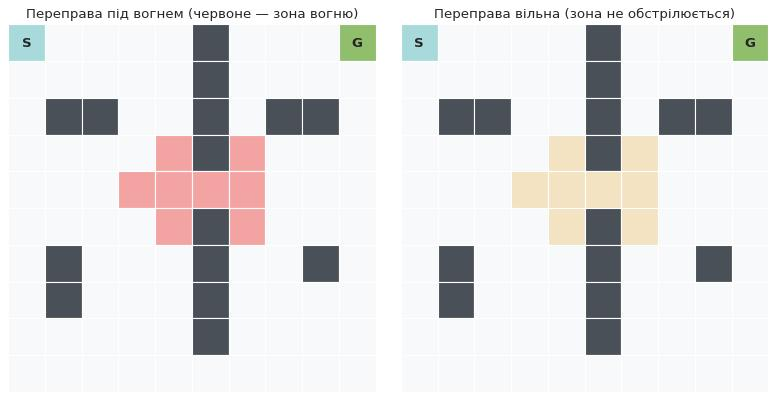

In [2]:
GRID = [
    "S....#...G",
    ".....#....",
    ".##..#.##.",
    "....T#T...",
    "...TTTT...",
    "....T#T...",
    ".#...#..#.",
    ".#...#....",
    ".....#....",
    "..........",
]
H, W = len(GRID), len(GRID[0])
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ARROWS = ["↑", "↓", "←", "→"]
start = next((r, c) for r in range(H) for c in range(W) if GRID[r][c] == "S")
goal = next((r, c) for r in range(H) for c in range(W) if GRID[r][c] == "G")
R_STEP, R_THREAT, R_GOAL, SLIP, P_FIRE = -1.0, -25.0, 100.0, 0.10, 0.5
N_OBS = H * W + 1

class RouteEnv:
    """Колона S→G. На початку рейсу розвідка повідомляє, чи коротка переправа під вогнем (fire = 1)."""
    def __init__(self, seed=0, p_fire=P_FIRE):
        self.rng, self.p_fire = np.random.default_rng(seed), p_fire
    def obs(self):
        o = np.zeros(N_OBS, np.float32); o[self.pos[0] * W + self.pos[1]] = 1.0; o[-1] = self.fire
        return o
    def reset(self, fire=None):
        self.pos = start
        self.fire = int(self.rng.random() < self.p_fire) if fire is None else int(fire)
        return self.obs()
    def step(self, a):
        if self.rng.random() < SLIP:                       # невизначеність руху
            a = int(self.rng.integers(4))
        dr, dc = ACTIONS[a]
        r, c = self.pos[0] + dr, self.pos[1] + dc
        if 0 <= r < H and 0 <= c < W and GRID[r][c] != "#":
            self.pos = (r, c)
        threat = self.fire == 1 and GRID[self.pos[0]][self.pos[1]] == "T"
        reward = R_STEP + (R_THREAT if threat else 0.0)
        done = self.pos == goal
        if done:
            reward += R_GOAL
        return self.obs(), reward, done, threat

def draw(ax, path=None, policy=None, fire=1, title=""):
    colors = {"#": "#495057", "T": "#f4a3a3" if fire else "#f3e3c3", ".": "#f8f9fa", "S": "#a8dadc", "G": "#90be6d"}
    for r in range(H):
        for c in range(W):
            ax.add_patch(plt.Rectangle((c, r), 1, 1, color=colors[GRID[r][c]], ec="white"))
            if GRID[r][c] in "SG":
                ax.text(c + .5, r + .5, GRID[r][c], ha="center", va="center", fontweight="bold")
            elif policy is not None and GRID[r][c] != "#":
                ax.text(c + .5, r + .5, ARROWS[policy[r, c]], ha="center", va="center", fontsize=11, color="#1d3557")
    if path:
        ax.plot([p[1] + .5 for p in path], [p[0] + .5 for p in path], "-o", color="#1d3557", lw=2.5, ms=4)
    ax.set_xlim(0, W); ax.set_ylim(H, 0); ax.set_aspect("equal"); ax.axis("off"); ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
draw(axes[0], fire=1, title="Переправа під вогнем (червоне — зона вогню)")
draw(axes[1], fire=0, title="Переправа вільна (зона не обстрілюється)")
plt.tight_layout(); plt.show()

## 2. Baseline-правила
- **BFS (найкоротший шлях):** завжди коротка переправа, розвіддані ігноруються.
- **Завжди обхід:** завжди довга безпечна переправа, розвіддані ігноруються.

Обидва правила при зносі колони перебудовують маршрут від поточної точки.

In [3]:
def bfs(src, avoid_threat=False):
    # Найкоротший шлях (Дейкстра). avoid_threat=True: крок у зону вогню «коштує» +50, тобто маршрут обходить її, якщо це можливо
    import heapq
    dist, prev, pq = {src: 0}, {src: None}, [(0, src)]
    while pq:
        d, cur = heapq.heappop(pq)
        if cur == goal: break
        if d > dist[cur]: continue
        for dr, dc in ACTIONS:
            n = (cur[0] + dr, cur[1] + dc)
            if 0 <= n[0] < H and 0 <= n[1] < W and GRID[n[0]][n[1]] != "#":
                nd = d + 1 + (50 if avoid_threat and GRID[n[0]][n[1]] == "T" else 0)
                if nd < dist.get(n, 1e9):
                    dist[n], prev[n] = nd, cur; heapq.heappush(pq, (nd, n))
    path, cur = [], goal
    while cur is not None: path.append(cur); cur = prev[cur]
    return path[::-1]

def rule_policy(avoid_threat):
    cache = {}
    def act(env):
        s = env.pos
        if s not in cache:
            p = bfs(s, avoid_threat)
            cache[s] = ACTIONS.index((p[1][0] - s[0], p[1][1] - s[1])) if len(p) > 1 else 0
        return cache[s]
    return act

short, safe = bfs(start), bfs(start, avoid_threat=True)
print(f"Коротка переправа: {len(short) - 1} кроків, клітин зони вогню: {sum(GRID[r][c] == 'T' for r, c in short)}")
print(f"Обхід:             {len(safe) - 1} кроків, клітин зони вогню: {sum(GRID[r][c] == 'T' for r, c in safe)}")

Коротка переправа: 17 кроків, клітин зони вогню: 5
Обхід:             27 кроків, клітин зони вогню: 0


## 3. Контрольний метод: табличний Q-learning
Для малої карти Q-функцію можна зберігати таблицею (2 × 10 × 10 × 4 значень). Цей метод використовується як еталон, з яким порівнюється DQN.

In [4]:
def q_learning(episodes=4000, alpha=0.1, gamma=0.99, seed=SEED):
    rng, env = np.random.default_rng(seed), RouteEnv(seed)
    Q = np.zeros((2, H, W, 4))
    for ep in range(episodes):
        eps = max(0.05, 1 - 0.95 * ep / (0.7 * episodes))
        env.reset(); f = env.fire
        for t in range(200):
            s = env.pos
            a = int(rng.integers(4)) if rng.random() < eps else int(np.argmax(Q[f][s]))
            _, r, done, _ = env.step(a)
            Q[f][s][a] += alpha * (r + (0 if done else gamma * Q[f][env.pos].max()) - Q[f][s][a])
            if done: break
    return Q

t0 = time.time(); Q_tab = q_learning()
print(f"Табличний Q-learning: {time.time() - t0:.1f} s")

Табличний Q-learning: 2.1 s


## 4. DQN-агент
Q-функція апроксимується нейронною мережею `101 → Dense(128, ReLU) → Dense(128, ReLU) → 4`, яка повертає цінність кожної з 4 дій.

Два прийоми стабілізують навчання (як у прикладі викладача):
- **experience replay:** переходи (s, a, r, s′, done) зберігаються в буфері на 20 000 записів, мережа навчається на випадкових батчах по 64. Це розриває кореляцію між послідовними кроками;
- **target network:** цільове значення $y = r + \gamma \max_{a'} Q_{target}(s', a')$ рахує окрема копія мережі, яка оновлюється кожні 500 кроків.

Функція втрат Huber, оптимізатор Adam (lr = 1e-3), γ = 0.99. Стратегія ε-greedy: ε зменшується з 1.0 до 0.05 за перші 60 % епізодів. Разом 1500 епізодів, максимум 150 кроків в епізоді.

In [5]:
CFG = dict(episodes=1500, max_steps=150, buffer=20_000, batch=64, gamma=0.99, lr=1e-3,
           target_update=500, train_every=2, warmup=1000, eps_end=0.05, eps_decay_frac=0.6)

def make_q_net():
    return keras.Sequential([keras.Input((N_OBS,)), layers.Dense(128, activation="relu"),
                             layers.Dense(128, activation="relu"), layers.Dense(4)])
q_net, target_net = make_q_net(), make_q_net()
target_net.set_weights(q_net.get_weights())
optimizer, huber = keras.optimizers.Adam(CFG["lr"]), keras.losses.Huber()
q_net.summary()

@tf.function
def q_values(x):
    return q_net(x)

@tf.function
def train_step(s, a, r, s2, d):
    target = r + CFG["gamma"] * (1.0 - d) * tf.reduce_max(target_net(s2), axis=1)
    with tf.GradientTape() as tape:
        q_sa = tf.reduce_sum(q_net(s) * tf.one_hot(a, 4), axis=1)
        loss = huber(target, q_sa)
    optimizer.apply_gradients(zip(tape.gradient(loss, q_net.trainable_variables), q_net.trainable_variables))
    return loss

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,084 (117.52 KB)

 Trainable params: 30,084 (117.52 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
B = CFG["buffer"]
buf_s, buf_s2 = np.zeros((B, N_OBS), np.float32), np.zeros((B, N_OBS), np.float32)
buf_a, buf_r, buf_d = np.zeros(B, np.int32), np.zeros(B, np.float32), np.zeros(B, np.float32)
env, rng = RouteEnv(SEED), np.random.default_rng(SEED)
n_stored, step, log, losses = 0, 0, [], []
t0 = time.time()
for ep in range(CFG["episodes"]):
    eps = max(CFG["eps_end"], 1 - (1 - CFG["eps_end"]) * ep / (CFG["eps_decay_frac"] * CFG["episodes"]))
    s, total, threat = env.reset(), 0.0, 0
    for t in range(CFG["max_steps"]):
        a = int(rng.integers(4)) if rng.random() < eps else int(np.argmax(q_values(s[None]).numpy()))
        s2, r, done, th = env.step(a)
        i = n_stored % B
        buf_s[i], buf_a[i], buf_r[i], buf_s2[i], buf_d[i] = s, a, r, s2, float(done)
        n_stored += 1; step += 1
        s, total, threat = s2, total + r, threat + th
        if n_stored >= CFG["warmup"] and step % CFG["train_every"] == 0:
            j = rng.integers(0, min(n_stored, B), CFG["batch"])
            losses.append(float(train_step(buf_s[j], buf_a[j], buf_r[j], buf_s2[j], buf_d[j])))
        if step % CFG["target_update"] == 0:
            target_net.set_weights(q_net.get_weights())
        if done: break
    log.append({"episode": ep, "reward": total, "steps": t + 1, "threat": threat, "success": done, "fire": env.fire, "eps": eps})
log = pd.DataFrame(log)
print(f"Навчання DQN: {time.time() - t0:.0f} s, {step} кроків середовища, {len(losses)} оновлень мережі")
os.makedirs("models", exist_ok=True)
q_net.save("models/dqn_route_agent.keras")

Навчання DQN: 88 s, 81653 кроків середовища, 40327 оновлень мережі


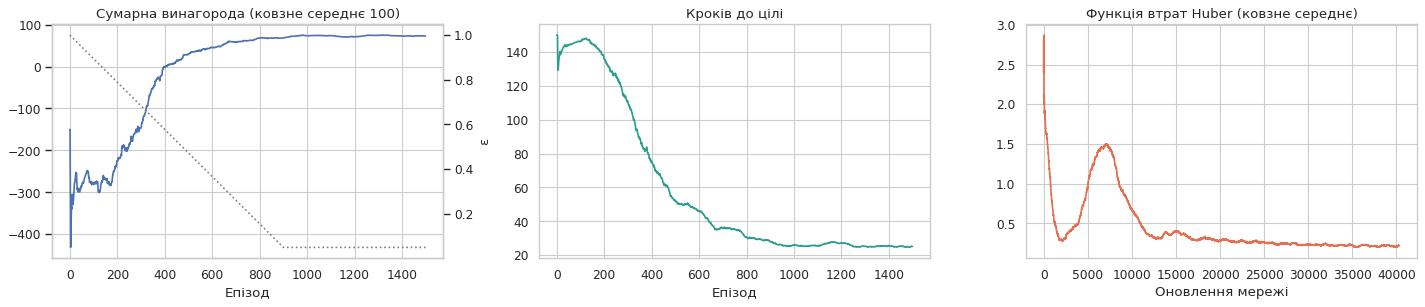

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
roll = log.rolling(100, min_periods=1).mean()
axes[0].plot(roll["reward"]); axes[0].set_title("Сумарна винагорода (ковзне середнє 100)"); axes[0].set_xlabel("Епізод")
ax2 = axes[0].twinx(); ax2.plot(log["eps"], color="gray", ls=":"); ax2.set_ylabel("ε"); ax2.grid(False)
axes[1].plot(roll["steps"], color="#2a9d8f"); axes[1].set_title("Кроків до цілі"); axes[1].set_xlabel("Епізод")
axes[2].plot(pd.Series(losses).rolling(500, min_periods=1).mean(), color="#e76f51")
axes[2].set_title("Функція втрат Huber (ковзне середнє)"); axes[2].set_xlabel("Оновлення мережі")
plt.tight_layout(); plt.show()

## 5. Оцінка: 500 рейсів для кожної умови розвідки

In [8]:
def evaluate(act, fire, n=500, seed=7):
    env, res = RouteEnv(seed), []
    for _ in range(n):
        o, total, threat = env.reset(fire), 0.0, 0
        for k in range(1, 201):
            o, r, done, th = env.step(act(env, o))
            total += r; threat += th
            if done: break
        res.append((total, k, threat, done))
    r = np.array(res, float)
    return {"успіх, %": 100 * r[:, 3].mean(), "сер. винагорода": r[:, 0].mean(),
            "сер. кроків": r[:, 1].mean(), "сер. кроків під вогнем": r[:, 2].mean()}

rng_eval = np.random.default_rng(1)
bfs_act, safe_act = rule_policy(False), rule_policy(True)
agents = {
    "Випадкова політика": lambda env, o: int(rng_eval.integers(4)),
    "Правило: коротка переправа (BFS)": lambda env, o: bfs_act(env),
    "Правило: завжди обхід": lambda env, o: safe_act(env),
    "Табличний Q-learning": lambda env, o: int(np.argmax(Q_tab[env.fire][env.pos])),
    "DQN-агент": lambda env, o: int(np.argmax(q_values(o[None]).numpy())),
}
rows = []
for fire, cond in [(0, "переправа вільна"), (1, "переправа під вогнем")]:
    for name, act in agents.items():
        rows.append({"умова": cond, "агент": name, **evaluate(act, fire)})
res = pd.DataFrame(rows)
res.round(2).set_index(["умова", "агент"])

успіх, %  \
умова                агент                                        
переправа вільна     Випадкова політика                     9.0   
                     Правило: коротка переправа (BFS)     100.0   
                     Правило: завжди обхід                100.0   
                     Табличний Q-learning                 100.0   
                     DQN-агент                            100.0   
переправа під вогнем Випадкова політика                     7.0   
                     Правило: коротка переправа (BFS)     100.0   
                     Правило: завжди обхід                100.0   
                     Табличний Q-learning                 100.0   
                     DQN-агент                            100.0   

                                                       сер. винагорода  \
умова                агент                                               
переправа вільна     Випадкова політика                        -184.67   
                     Правило: коротка переправа (BFS)            81.04   
                     Правило: завжди обхід                       69.87   
                     Табличний Q-learning                        81.04   
                     DQN-агент                                   80.85   
переправа під вогнем Випадкова політика                        -585.28   
                     Правило: коротка переправа (BFS)           -59.71   
                     Правило: завжди обхід                       65.07   
                     Табличний Q-learning                        69.15   
                     DQN-агент                                   68.32   

                                                       сер. кроків  \
умова                агент                                           
переправа вільна     Випадкова політика                     193.67   
                     Правило: коротка переправа (BFS)        18.96   
                     Правило: завжди обхід                   30.13   
                     Табличний Q-learning                    18.96   
                     DQN-агент                               19.15   
переправа під вогнем Випадкова політика                     195.03   
                     Правило: коротка переправа (BFS)        18.96   
                     Правило: завжди обхід                   30.13   
                     Табличний Q-learning                    30.20   
                     DQN-агент                               30.13   

                                                       сер. кроків під вогнем  
умова                агент                                                     
переправа вільна     Випадкова політика                                  0.00  
                     Правило: коротка переправа (BFS)                    0.00  
                     Правило: завжди обхід                               0.00  
                     Табличний Q-learning                                0.00  
                     DQN-агент                                           0.00  
переправа під вогнем Випадкова політика                                 15.89  
                     Правило: коротка переправа (BFS)                    5.63  
                     Правило: завжди обхід                               0.19  
                     Табличний Q-learning                                0.03  
                     DQN-агент                                           0.06

In [9]:
overall = res.groupby("агент", sort=False)[["успіх, %", "сер. винагорода", "сер. кроків", "сер. кроків під вогнем"]].mean()
print("Середнє за обома умовами (рівноймовірні, як у навчанні):")
overall.round(2)

Середнє за обома умовами (рівноймовірні, як у навчанні):


,"успіх, %",сер. винагорода,сер. кроків,сер. кроків під вогнем
агент,,,,
Випадкова політика,8.0,-384.97,194.35,7.94
Правило: коротка переправа (BFS),100.0,10.66,18.96,2.82
Правило: завжди обхід,100.0,67.47,30.13,0.10
Табличний Q-learning,100.0,75.10,24.58,0.01
DQN-агент,100.0,74.59,24.64,0.03


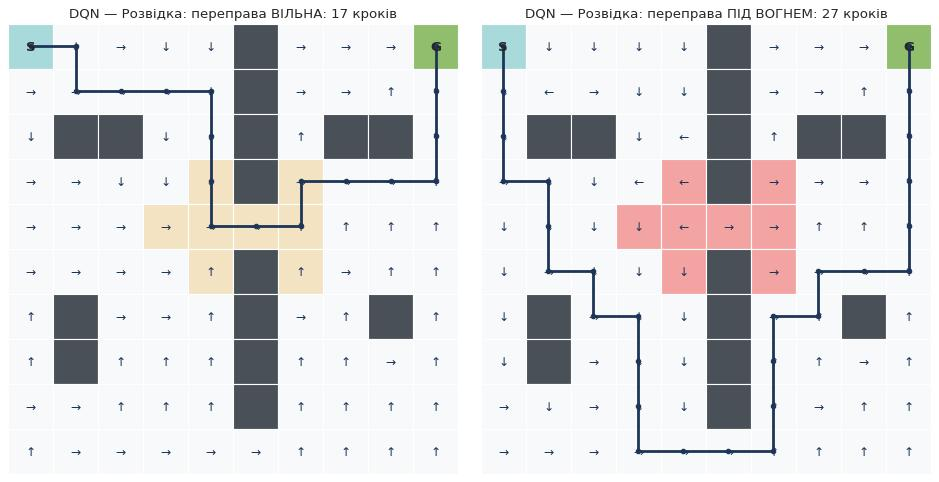

In [10]:
def greedy(fire, max_len=60):
    pol = np.zeros((H, W), int)
    for r in range(H):
        for c in range(W):
            o = np.zeros(N_OBS, np.float32); o[r * W + c] = 1; o[-1] = fire
            pol[r, c] = int(np.argmax(q_values(o[None]).numpy()))
    s, path = start, [start]
    while s != goal and len(path) < max_len:
        dr, dc = ACTIONS[pol[s]]; n = (s[0] + dr, s[1] + dc)
        if not (0 <= n[0] < H and 0 <= n[1] < W) or GRID[n[0]][n[1]] == "#": break
        s = n; path.append(s)
    return pol, path

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, fire, t in [(axes[0], 0, "Розвідка: переправа ВІЛЬНА"), (axes[1], 1, "Розвідка: переправа ПІД ВОГНЕМ")]:
    pol, path = greedy(fire)
    draw(ax, path=path, policy=pol, fire=fire, title=f"DQN — {t}: {len(path) - 1} кроків")
plt.tight_layout(); plt.show()

## 6. Чутливість до ціни ризику (на табличному Q-learning, який навчається за секунди)
Штраф за крок під вогнем задає командир, і саме він визначає, наскільки агент готовий ризикувати заради часу.

In [11]:
sens = []
for penalty in [0, -1, -5, -25, -60]:
    R_THREAT = penalty
    Qp = q_learning(seed=SEED)
    e = evaluate(lambda env, o: int(np.argmax(Qp[env.fire][env.pos])), fire=1, n=300)
    sens.append({"штраф за крок під вогнем": penalty, "сер. кроків": e["сер. кроків"], "сер. кроків під вогнем": e["сер. кроків під вогнем"]})
R_THREAT = -25.0
pd.DataFrame(sens).round(2)

,штраф за крок під вогнем,сер. кроків,сер. кроків під вогнем
0,0,19.11,4.49
1,-1,19.05,4.49
2,-5,19.11,4.49
3,-25,30.26,0.02
4,-60,30.16,0.00


## 7. Висновки (частина 2)

1. **DQN-агент навчився враховувати розвіддані.** Якщо переправа вільна, він їде коротким шляхом (≈ 19 кроків, як BFS). Якщо переправа під вогнем, обходить її через безпечну переправу (≈ 30 кроків, 0.06 кроку під вогнем на рейс). Обидва маршрути видно на картах політики. Одна й та сама мережа поводиться по-різному залежно від ознаки розвідки у вхідних даних.
2. **Агент кращий за кожне фіксоване правило.** Середня винагорода за обома умовами: DQN **74.6**; «завжди коротка переправа» (BFS) 10.7 (під вогнем колона проходить ≈ 5.6 клітини зони обстрілу за рейс); «завжди обхід» 67.5 (у половині рейсів колона витрачає зайві 11 кроків). Агент поєднує переваги обох правил: швидкість, коли безпечно, і обережність, коли є загроза.
3. **DQN досяг рівня точного табличного методу** (74.6 проти 75.1, кроків під вогнем 0.03 проти 0.01 у середньому). Для карти 10×10 таблиця ще працює, але її розмір зростає з кожною новою ознакою стану (час, пальне, кілька загроз, стан зв'язку). Нейромережа масштабується на такі стани, тому для реальних задач потрібен саме DQN або Actor-Critic.
4. **Навчання стабільне завдяки experience replay і target network.** Винагорода виходить на плато після ≈ 900 епізодів (≈ 90 s на CPU). Сплеск функції втрат на початку відповідає моменту, коли агент уперше почав доїжджати до цілі й отримувати +100, після чого оцінки Q стабілізуються.
5. **Рішення визначає ціна ризику, яку задає командир.** Коли штраф за крок під вогнем становить 0…−5, агент свідомо йде через зону обстрілу, бо з дисконтуванням (γ = 0.99) затримка на 10 кроків «коштує» порівнянно. Починаючи з −25, він стабільно обходить загрозу. Формулювання винагороди — управлінське, а не технічне рішення.

**Обмеження:** відома статична карта з однією змінною загрозою, спрощена модель руху, достовірні розвіддані. **Наступні кроки:** кілька динамічних загроз і неповна або хибна розвідка, обмеження за часом і пальним, порівняння DQN з Actor-Critic (PPO).